# 02 - Intermediate: Recipe Types & Visualizations

This notebook explores py2dataiku's recipe types in depth, demonstrates how to inspect recipe attributes and settings, and covers all available visualization formats and themes.

**Prerequisites:** Completion of `01_beginner.ipynb` or familiarity with `convert()` and `DataikuFlow`.

**What you will learn:**
- All major recipe types and the pandas code that triggers each one
- The `RecipeType` enum and `DataikuRecipe` attributes
- Recipe settings classes (`GroupingSettings`, `JoinSettings`, etc.)
- All 6 visualization formats: SVG, ASCII, HTML, Mermaid, PlantUML, Interactive
- Theme support: `DATAIKU_LIGHT` vs `DATAIKU_DARK`
- Jupyter inline display with `_repr_svg_()`
- YAML round-trip serialization

---
## 1. Setup

In [1]:
import sys
sys.path.insert(0, "../..")

from py2dataiku import (
    convert,
    DataikuFlow,
    DataikuRecipe,
    RecipeType,
    Aggregation,
    JoinKey,
    JoinType,
    AggregationFunction,
    WindowFunctionType,
    SplitMode,
    SamplingMethod,
)
from py2dataiku.models.recipe_settings import (
    RecipeSettings,
    PrepareSettings,
    GroupingSettings,
    JoinSettings,
    WindowSettings,
    SortSettings,
    DistinctSettings,
    TopNSettings,
    PivotSettings,
    SplitSettings,
    SamplingSettings,
    StackSettings,
)
from py2dataiku.visualizers import (
    visualize_flow,
    SVGVisualizer,
    ASCIIVisualizer,
    HTMLVisualizer,
    PlantUMLVisualizer,
    MermaidVisualizer,
    InteractiveVisualizer,
    DataikuTheme,
    DATAIKU_LIGHT,
    DATAIKU_DARK,
)

print("All imports successful.")

All imports successful.


### `convert()` accepts `pathlib.Path` and `.py` paths directly

Wave-3 made `convert()` and `convert_with_llm()` polymorphic — they accept inline source code, a `pathlib.Path` to a `.py` file, or a string path ending in `.py`. The function detects which you passed and reads the file when needed. The CLI also supports a bare-file form: `py2dataiku script.py` auto-routes to the `convert` subcommand.

In [2]:
import tempfile
from pathlib import Path

# Write a small pandas script to disk
with tempfile.NamedTemporaryFile(mode='w', suffix='.py', delete=False) as f:
    f.write("import pandas as pd\ndf = pd.read_csv('x.csv').dropna()\n")
    tmp_script = f.name

# All three forms produce the same flow:
via_path = convert(Path(tmp_script))    # pathlib.Path
via_str = convert(tmp_script)            # string path
via_inline = convert("""
import pandas as pd
df = pd.read_csv('x.csv').dropna()
""")

print(f'Path:   {len(via_path.recipes)} recipes')
print(f'String: {len(via_str.recipes)} recipes')
print(f'Inline: {len(via_inline.recipes)} recipes')

import os
os.unlink(tmp_script)


Path:   2 recipes
String: 2 recipes
Inline: 2 recipes


---
## 2. The RecipeType Enum

Dataiku DSS has 37 recipe types. py2dataiku models them as the `RecipeType` enum, grouped into visual recipes, code recipes, and ML recipes.

In [3]:
# List all recipe types
print(f"Total recipe types: {len(RecipeType)}\n")

for rt in RecipeType:
    print(f"  {rt.name:<30s} -> {rt.value!r}")

Total recipe types: 37

  PREPARE                        -> 'prepare'
  SYNC                           -> 'sync'
  GROUPING                       -> 'grouping'
  WINDOW                         -> 'window'
  JOIN                           -> 'join'
  FUZZY_JOIN                     -> 'fuzzyjoin'
  GEO_JOIN                       -> 'geojoin'
  STACK                          -> 'stack'
  SPLIT                          -> 'split'
  SORT                           -> 'sort'
  DISTINCT                       -> 'distinct'
  TOP_N                          -> 'topn'
  PIVOT                          -> 'pivot'
  SAMPLING                       -> 'sampling'
  DOWNLOAD                       -> 'download'
  GENERATE_FEATURES              -> 'generate_features'
  GENERATE_STATISTICS            -> 'generate_statistics'
  PUSH_TO_EDITABLE               -> 'push_to_editable'
  LIST_FOLDER_CONTENTS           -> 'list_folder_contents'
  DYNAMIC_REPEAT                 -> 'dynamic_repeat'
  EXTRACT_FAILED_R

In [4]:
# RecipeType enum usage: access by name or value
print("By name:  ", RecipeType.GROUPING)
print("By value: ", RecipeType("grouping"))
print("Value:    ", RecipeType.GROUPING.value)
print("Name:     ", RecipeType.GROUPING.name)

By name:   RecipeType.GROUPING
By value:  RecipeType.GROUPING
Value:     grouping
Name:      GROUPING


---
## 3. Recipe Types in Action

Each subsection shows the pandas code that maps to a specific Dataiku recipe type, converts it, and inspects the result.

### 3.1 PREPARE Recipe

The Prepare recipe handles column-level transformations like renaming, filling nulls, dropping rows, and type conversions. Most pandas method calls on a single DataFrame map to processors within a Prepare recipe.

In [5]:
prepare_code = """
import pandas as pd
df = pd.read_csv('sales.csv')
df = df.fillna(0)
df = df.rename(columns={'old_name': 'new_name'})
df = df.dropna()
"""

flow = convert(prepare_code)
print(flow.get_summary())

Flow: converted_flow
Source: unknown
Generated: 2026-04-27T22:44:57.690942

Datasets: 2
  - Input: 1
  - Intermediate: 1
  - Output: 0

Recipes: 1
  - prepare: 1

Optimization Notes:
  - prepare: 1 recipe(s)


In [6]:
# Inspect the Prepare recipe's attributes
for recipe in flow.recipes:
    if recipe.recipe_type == RecipeType.PREPARE:
        print(f"Name:        {recipe.name}")
        print(f"Type:        {recipe.recipe_type}")
        print(f"Inputs:      {recipe.inputs}")
        print(f"Outputs:     {recipe.outputs}")
        print(f"Steps:       {len(recipe.steps)}")
        for i, step in enumerate(recipe.steps):
            print(f"  Step {i+1}: {step.processor_type.value} -> {step.get_description()}")
        break

Name:        prepare_1
Type:        RecipeType.PREPARE
Inputs:      ['df']
Outputs:     ['df_prepared']
Steps:       3
  Step 1: RemoveRowsOnEmpty -> Remove rows with empty values in: all columns
  Step 2: FillEmptyWithValue -> Fill empty values in 'unknown' with '0'
  Step 3: ColumnRenamer -> Rename columns: old_name -> new_name


### 3.2 GROUPING Recipe

Pandas `groupby().agg()` maps to a Dataiku Grouping recipe.

In [7]:
grouping_code = """
import pandas as pd
df = pd.read_csv('orders.csv')
result = df.groupby('category').agg({'amount': 'sum', 'quantity': 'mean'})
"""

flow = convert(grouping_code)
print(flow.get_summary())
print()

# Inspect grouping recipe details
for recipe in flow.recipes:
    if recipe.recipe_type == RecipeType.GROUPING:
        print(f"Group keys:    {recipe.group_keys}")
        print(f"Aggregations:  {len(recipe.aggregations)}")
        for agg in recipe.aggregations:
            print(f"  {agg.column} -> {agg.function}")

Flow: converted_flow
Source: unknown
Generated: 2026-04-27T22:44:57.697498

Datasets: 2
  - Input: 1
  - Intermediate: 1
  - Output: 0

Recipes: 1
  - grouping: 1

Optimization Notes:
  - grouping: 1 recipe(s)

Group keys:    ['category']
Aggregations:  2
  amount -> SUM
  quantity -> AVG


### 3.3 JOIN Recipe

Pandas `pd.merge()` or `df.merge()` maps to a Join recipe.

In [8]:
join_code = """
import pandas as pd
orders = pd.read_csv('orders.csv')
customers = pd.read_csv('customers.csv')
result = pd.merge(orders, customers, on='customer_id', how='left')
"""

flow = convert(join_code)
print(flow.get_summary())
print()

for recipe in flow.recipes:
    if recipe.recipe_type == RecipeType.JOIN:
        print(f"Join type:  {recipe.join_type}")
        print(f"Join keys:  {len(recipe.join_keys)}")
        for key in recipe.join_keys:
            print(f"  Left: {key.left_column}  <->  Right: {key.right_column}")

Flow: converted_flow
Source: unknown
Generated: 2026-04-27T22:44:57.700956

Datasets: 3
  - Input: 2
  - Intermediate: 1
  - Output: 0

Recipes: 1
  - join: 1

Optimization Notes:
  - join: 1 recipe(s)

Join type:  JoinType.LEFT
Join keys:  1
  Left: customer_id  <->  Right: customer_id


### 3.4 STACK Recipe

Pandas `pd.concat()` maps to a Stack recipe (union of datasets).

In [9]:
stack_code = """
import pandas as pd
df1 = pd.read_csv('sales_q1.csv')
df2 = pd.read_csv('sales_q2.csv')
combined = pd.concat([df1, df2])
"""

flow = convert(stack_code)
print(flow.get_summary())
print()

for recipe in flow.recipes:
    if recipe.recipe_type == RecipeType.STACK:
        print(f"Inputs:  {recipe.inputs}")
        print(f"Outputs: {recipe.outputs}")

Flow: converted_flow
Source: unknown
Generated: 2026-04-27T22:44:57.703956

Datasets: 3
  - Input: 2
  - Intermediate: 1
  - Output: 0

Recipes: 1
  - stack: 1

Optimization Notes:
  - stack: 1 recipe(s)

Inputs:  ['df1', 'df2']
Outputs: ['combined']


### 3.5 SORT Recipe

Pandas `df.sort_values()` maps to a Sort recipe.

In [10]:
sort_code = """
import pandas as pd
df = pd.read_csv('products.csv')
df = df.sort_values('price', ascending=False)
"""

flow = convert(sort_code)
print(flow.get_summary())
print()

for recipe in flow.recipes:
    if recipe.recipe_type == RecipeType.SORT:
        print(f"Sort columns: {recipe.sort_columns}")

Flow: converted_flow
Source: unknown
Generated: 2026-04-27T22:44:57.706968

Datasets: 2
  - Input: 1
  - Intermediate: 1
  - Output: 0

Recipes: 1
  - sort: 1

Optimization Notes:
  - sort: 1 recipe(s)

Sort columns: [{'column': 'price', 'order': 'DESC'}]


### 3.6 DISTINCT Recipe

Pandas `df.drop_duplicates()` maps to a Distinct recipe.

In [11]:
distinct_code = """
import pandas as pd
df = pd.read_csv('events.csv')
df = df.drop_duplicates()
"""

flow = convert(distinct_code)
print(flow.get_summary())

Flow: converted_flow
Source: unknown
Generated: 2026-04-27T22:44:57.709955

Datasets: 2
  - Input: 1
  - Intermediate: 1
  - Output: 0

Recipes: 1
  - prepare: 1

Optimization Notes:
  - prepare: 1 recipe(s)


### 3.7 TOP_N Recipe

Pandas `df.nlargest()` or `df.nsmallest()` maps to a Top N recipe.

In [12]:
topn_code = """
import pandas as pd
df = pd.read_csv('scores.csv')
top_10 = df.nlargest(10, 'score')
"""

flow = convert(topn_code)
print(flow.get_summary())
print()

for recipe in flow.recipes:
    if recipe.recipe_type == RecipeType.TOP_N:
        print(f"Top N:           {recipe.top_n}")
        print(f"Ranking column:  {recipe.ranking_column}")

Flow: converted_flow
Source: unknown
Generated: 2026-04-27T22:44:57.713189

Datasets: 2
  - Input: 1
  - Intermediate: 1
  - Output: 0

Recipes: 1
  - topn: 1

Optimization Notes:
  - topn: 1 recipe(s)

Top N:           10
Ranking column:  score


### 3.8 WINDOW Recipe

Pandas `df.rolling()` and cumulative functions like `df.cumsum()` map to a Window recipe.

In [13]:
window_code = """
import pandas as pd
df = pd.read_csv('timeseries.csv')
df['cumulative_sales'] = df['sales'].cumsum()
"""

flow = convert(window_code)
print(flow.get_summary())
print()

for recipe in flow.recipes:
    if recipe.recipe_type == RecipeType.WINDOW:
        print(f"Partition columns: {recipe.partition_columns}")
        print(f"Order columns:     {recipe.order_columns}")
        print(f"Aggregations:      {recipe.window_aggregations}")

Flow: converted_flow
Source: unknown
Generated: 2026-04-27T22:44:57.716858

Datasets: 2
  - Input: 1
  - Intermediate: 1
  - Output: 0

Recipes: 1
  - window: 1

Optimization Notes:
  - window: 1 recipe(s)

Partition columns: []
Order columns:     []
Aggregations:      []


### 3.9 PIVOT Recipe

Pandas `df.pivot()` or `df.pivot_table()` maps to a Pivot recipe.

In [14]:
pivot_code = """
import pandas as pd
df = pd.read_csv('sales.csv')
pivoted = df.pivot_table(index='region', columns='product', values='revenue', aggfunc='sum')
"""

flow = convert(pivot_code)
print(flow.get_summary())

Flow: converted_flow
Source: unknown
Generated: 2026-04-27T22:44:57.719933

Datasets: 2
  - Input: 1
  - Intermediate: 1
  - Output: 0

Recipes: 1
  - pivot: 1

Optimization Notes:
  - pivot: 1 recipe(s)


### 3.10 SPLIT Recipe

Pandas conditional filtering like `df[condition]` can map to a Split recipe.

In [15]:
split_code = """
import pandas as pd
df = pd.read_csv('users.csv')
active = df[df['status'] == 'active']
inactive = df[df['status'] != 'active']
"""

flow = convert(split_code)
print(flow.get_summary())

Flow: converted_flow
Source: unknown
Generated: 2026-04-27T22:44:57.723057

Datasets: 3
  - Input: 1
  - Intermediate: 2
  - Output: 0

Recipes: 2
  - split: 2

Optimization Notes:
  - split: 2 recipe(s)


### 3.11 SAMPLING Recipe

Pandas `df.sample()` or `df.head()` maps to a Sampling recipe.

In [16]:
sampling_code = """
import pandas as pd
df = pd.read_csv('large_dataset.csv')
sample = df.sample(n=1000)
"""

flow = convert(sampling_code)
print(flow.get_summary())
print()

for recipe in flow.recipes:
    if recipe.recipe_type == RecipeType.SAMPLING:
        print(f"Method:      {recipe.sampling_method}")
        print(f"Sample size: {recipe.sample_size}")

Flow: converted_flow
Source: unknown
Generated: 2026-04-27T22:44:57.726136

Datasets: 2
  - Input: 1
  - Intermediate: 1
  - Output: 0

Recipes: 1
  - sampling: 1

Optimization Notes:
  - sampling: 1 recipe(s)

Method:      SamplingMethod.RANDOM
Sample size: 1000


### 3.12 New Recipe Handlers: WINDOW, PIVOT, TOP_N, SAMPLING in Detail

The following cells demonstrate that `convert()` now generates dedicated Dataiku visual
recipes for WINDOW, PIVOT, TOP_N, and SAMPLING operations -- previously these fell back
to generic Python recipes.

In [17]:
# WINDOW recipe from df.rolling().mean() -- now generates a Window recipe (not Python fallback)
window_rolling_code = """
import pandas as pd
df = pd.read_csv('timeseries.csv')
df['rolling_avg'] = df['sales'].rolling(7).mean()
"""

flow = convert(window_rolling_code)
print("Rolling window generates a WINDOW recipe:")
for recipe in flow.recipes:
    print(f"  {recipe.name}: {recipe.recipe_type.value}")
    if recipe.recipe_type == RecipeType.WINDOW:
        print(f"    Partition columns: {recipe.partition_columns}")
        print(f"    Order columns:     {recipe.order_columns}")
        print(f"    Window aggregations: {recipe.window_aggregations}")

Rolling window generates a WINDOW recipe:
  window_1: window
    Partition columns: []
    Order columns:     []
    Window aggregations: [{'column': 'sales', 'type': 'MEAN', 'windowSize': 7}]


In [18]:
# PIVOT recipe from df.pivot_table() -- now generates a Pivot recipe with PivotSettings
pivot_detail_code = """
import pandas as pd
df = pd.read_csv('quarterly_sales.csv')
pivoted = df.pivot_table(index='region', columns='quarter', values='revenue', aggfunc='sum')
"""

flow = convert(pivot_detail_code)
print("pivot_table() generates a PIVOT recipe:")
for recipe in flow.recipes:
    print(f"  {recipe.name}: {recipe.recipe_type.value}")
    if recipe.recipe_type == RecipeType.PIVOT and recipe.settings:
        print(f"    PivotSettings: {recipe.settings.to_dict()}")

pivot_table() generates a PIVOT recipe:
  pivot_1: pivot
    PivotSettings: {'rowColumns': [], 'columnColumn': '', 'valueColumn': '', 'aggregation': 'SUM'}


In [19]:
# TOP_N recipe from df.nlargest() -- now generates a TopN recipe (not Python fallback)
topn_detail_code = """
import pandas as pd
df = pd.read_csv('scores.csv')
top_5 = df.nlargest(5, 'score')
bottom_5 = df.nsmallest(5, 'score')
"""

flow = convert(topn_detail_code)
print("nlargest()/nsmallest() generate TOP_N recipes:")
for recipe in flow.recipes:
    print(f"  {recipe.name}: {recipe.recipe_type.value}")
    if recipe.recipe_type == RecipeType.TOP_N:
        print(f"    top_n={recipe.top_n}, ranking_column={recipe.ranking_column}")

nlargest()/nsmallest() generate TOP_N recipes:
  topn_1: topn
    top_n=5, ranking_column=score
  topn_2: topn
    top_n=5, ranking_column=score


In [20]:
# SAMPLING recipe from df.sample() -- now generates a Sampling recipe with correct method
sampling_detail_code = """
import pandas as pd
df = pd.read_csv('large_dataset.csv')
fixed_sample = df.sample(n=500)
head_sample = df.head(100)
"""

flow = convert(sampling_detail_code)
print("sample()/head() generate SAMPLING recipes:")
for recipe in flow.recipes:
    print(f"  {recipe.name}: {recipe.recipe_type.value}")
    if recipe.recipe_type == RecipeType.SAMPLING:
        print(f"    method={recipe.sampling_method}, size={recipe.sample_size}")

sample()/head() generate SAMPLING recipes:
  sampling_1: sampling
    method=SamplingMethod.RANDOM, size=500
  sampling_2: sampling
    method=SamplingMethod.FIRST_ROWS, size=100


---
## 4. DataikuRecipe Attributes Deep Dive

Every `DataikuRecipe` has common attributes plus type-specific ones.

In [21]:
# Build a multi-step flow to inspect recipe attributes
multi_code = """
import pandas as pd
df = pd.read_csv('data.csv')
df = df.fillna(0)
df = df.rename(columns={'old': 'new'})
grouped = df.groupby('category').agg({'value': 'sum'})
sorted_df = grouped.sort_values('value', ascending=False)
"""

flow = convert(multi_code)

for recipe in flow.recipes:
    print(f"--- {recipe} ---")
    print(f"  name:         {recipe.name}")
    print(f"  recipe_type:  {recipe.recipe_type}")
    print(f"  inputs:       {recipe.inputs}")
    print(f"  outputs:      {recipe.outputs}")
    print(f"  source_lines: {recipe.source_lines}")
    print(f"  notes:        {recipe.notes}")
    print(f"  settings:     {recipe.settings}")
    print()

--- DataikuRecipe(name='prepare_1', type=prepare) ---
  name:         prepare_1
  recipe_type:  RecipeType.PREPARE
  inputs:       ['df']
  outputs:      ['df_prepared']
  source_lines: []
  notes:        []
  settings:     None

--- DataikuRecipe(name='grouping_2', type=grouping) ---
  name:         grouping_2
  recipe_type:  RecipeType.GROUPING
  inputs:       ['df_prepared']
  outputs:      ['grouped']
  source_lines: [6]
  notes:        []
  settings:     None

--- DataikuRecipe(name='sort_3', type=sort) ---
  name:         sort_3
  recipe_type:  RecipeType.SORT
  inputs:       ['grouped']
  outputs:      ['grouped_sorted']
  source_lines: [7]
  notes:        []
  settings:     None



In [22]:
# The to_dict() method gives a serializable view of a recipe
import json

for recipe in flow.recipes:
    print(f"--- {recipe.name} ---")
    print(json.dumps(recipe.to_dict(), indent=2))
    print()

--- prepare_1 ---
{
  "name": "prepare_1",
  "type": "prepare",
  "inputs": [
    "df"
  ],
  "outputs": [
    "df_prepared"
  ],
  "source_lines": [],
  "notes": [],
  "steps": [
    {
      "metaType": "PROCESSOR",
      "type": "FillEmptyWithValue",
      "disabled": false,
      "params": {
        "column": "unknown",
        "value": "0"
      }
    },
    {
      "metaType": "PROCESSOR",
      "type": "ColumnRenamer",
      "disabled": false,
      "params": {
        "renamings": [
          {
            "from": "old",
            "to": "new"
          }
        ]
      }
    }
  ],
  "step_count": 2
}

--- grouping_2 ---
{
  "name": "grouping_2",
  "type": "grouping",
  "inputs": [
    "df_prepared"
  ],
  "outputs": [
    "grouped"
  ],
  "source_lines": [
    6
  ],
  "notes": [],
  "keys": [
    "category"
  ],
  "aggregations": [
    {
      "column": "value",
      "type": "SUM"
    }
  ]
}

--- sort_3 ---
{
  "name": "sort_3",
  "type": "sort",
  "inputs": [
    "groupe

In [23]:
# The to_api_dict() method gives the Dataiku API-compatible format
for recipe in flow.recipes:
    print(f"--- {recipe.name} (API format) ---")
    print(json.dumps(recipe.to_api_dict(), indent=2))
    print()

--- prepare_1 (API format) ---
{
  "type": "shaker",
  "name": "prepare_1",
  "inputs": {
    "main": {
      "items": [
        {
          "ref": "df",
          "appendMode": false
        }
      ]
    }
  },
  "outputs": {
    "main": {
      "items": [
        {
          "ref": "df_prepared",
          "appendMode": false
        }
      ]
    }
  },
  "versionTag": {
    "versionNumber": 0
  },
  "params": {
    "mode": "NORMAL",
    "steps": [
      {
        "metaType": "PROCESSOR",
        "type": "FillEmptyWithValue",
        "disabled": false,
        "params": {
          "column": "unknown",
          "value": "0"
        }
      },
      {
        "metaType": "PROCESSOR",
        "type": "ColumnRenamer",
        "disabled": false,
        "params": {
          "renamings": [
            {
              "from": "old",
              "to": "new"
            }
          ]
        }
      }
    ]
  }
}

--- grouping_2 (API format) ---
{
  "type": "grouping",
  "name": "group

### 4.1 Factory Methods

`DataikuRecipe` provides factory methods for common recipe types.

In [24]:
# Create recipes using factory methods
grouping = DataikuRecipe.create_grouping(
    name="compute_group_stats",
    input_dataset="cleaned_data",
    output_dataset="grouped_stats",
    keys=["region", "product"],
    aggregations=[
        Aggregation(column="revenue", function="SUM"),
        Aggregation(column="quantity", function="AVG"),
    ],
)
print(grouping)
print(f"Group keys:    {grouping.group_keys}")
print(f"Aggregations:  {[(a.column, a.function) for a in grouping.aggregations]}")

DataikuRecipe(name='compute_group_stats', type=grouping)
Group keys:    ['region', 'product']
Aggregations:  [('revenue', 'SUM'), ('quantity', 'AVG')]


In [25]:
# Factory: create_join
join_recipe = DataikuRecipe.create_join(
    name="join_orders_customers",
    left_dataset="orders",
    right_dataset="customers",
    output_dataset="orders_enriched",
    join_keys=[JoinKey(left_column="cust_id", right_column="id")],
    join_type=JoinType.LEFT,
)
print(join_recipe)
print(f"Join type: {join_recipe.join_type}")
print(f"Keys:      {[(k.left_column, k.right_column) for k in join_recipe.join_keys]}")

DataikuRecipe(name='join_orders_customers', type=join)
Join type: JoinType.LEFT
Keys:      [('cust_id', 'id')]


### 4.2 Helper Methods on DataikuRecipe

In [26]:
# add_aggregation and add_note
grouping.add_aggregation("revenue", "MAX", output_column="max_revenue")
grouping.add_note("Added max revenue aggregation")

print(f"Aggregations now: {len(grouping.aggregations)}")
for a in grouping.aggregations:
    print(f"  {a.column} -> {a.function} (output: {a.output_column})")

print(f"\nNotes: {grouping.notes}")

Aggregations now: 3
  revenue -> SUM (output: None)
  quantity -> AVG (output: None)
  revenue -> MAX (output: max_revenue)

Notes: ['Added max revenue aggregation']


In [27]:
# add_join_key
join_recipe.add_join_key("region_code", "region_code")
print(f"Join keys: {len(join_recipe.join_keys)}")
for k in join_recipe.join_keys:
    print(f"  {k.left_column} <-> {k.right_column} ({k.match_type})")

Join keys: 2
  cust_id <-> id (EXACT)
  region_code <-> region_code (EXACT)


---
## 5. Recipe Settings Classes

Recipe settings use a composition pattern. Each recipe type has its own settings dataclass that can be attached via `recipe.settings`.

In [28]:
# GroupingSettings
gs = GroupingSettings(
    keys=["department", "year"],
    aggregations=[
        Aggregation(column="salary", function="AVG"),
        Aggregation(column="salary", function="MAX"),
    ],
    global_count=True,
)
print("GroupingSettings.to_dict():")
print(json.dumps(gs.to_dict(), indent=2))
print("\nGroupingSettings.to_display_dict():")
print(json.dumps(gs.to_display_dict(), indent=2))

GroupingSettings.to_dict():
{
  "keys": [
    {
      "column": "department"
    },
    {
      "column": "year"
    }
  ],
  "aggregations": [
    {
      "column": "salary",
      "type": "AVG"
    },
    {
      "column": "salary",
      "type": "MAX"
    }
  ],
  "globalCount": true
}

GroupingSettings.to_display_dict():
{
  "keys": [
    "department",
    "year"
  ],
  "aggregations": [
    {
      "column": "salary",
      "type": "AVG"
    },
    {
      "column": "salary",
      "type": "MAX"
    }
  ]
}


In [29]:
# JoinSettings
js = JoinSettings(
    join_type="INNER",
    join_keys=[JoinKey(left_column="id", right_column="user_id")],
    selected_columns={"left": ["id", "name"], "right": ["email"]},
)
print("JoinSettings.to_dict():")
print(json.dumps(js.to_dict(), indent=2))

JoinSettings.to_dict():
{
  "joinType": "INNER",
  "joins": [
    {
      "left": {
        "column": "id"
      },
      "right": {
        "column": "user_id"
      },
      "matchType": "EXACT"
    }
  ],
  "selectedColumns": {
    "left": [
      "id",
      "name"
    ],
    "right": [
      "email"
    ]
  }
}


In [30]:
# WindowSettings
ws = WindowSettings(
    partition_columns=["department"],
    order_columns=["hire_date"],
    aggregations=[
        {"column": "salary", "type": WindowFunctionType.RUNNING_SUM},
        {"column": "employee_id", "type": WindowFunctionType.ROW_NUMBER},
    ],
)
print("WindowSettings.to_dict():")
# WindowFunctionType enums are serialized to their string values
print(json.dumps(ws.to_dict(), indent=2))

WindowSettings.to_dict():
{
  "partitionColumns": [
    {
      "column": "department"
    }
  ],
  "orderColumns": [
    {
      "column": "hire_date"
    }
  ],
  "aggregations": [
    {
      "column": "salary",
      "type": "RUNNING_SUM"
    },
    {
      "column": "employee_id",
      "type": "ROW_NUMBER"
    }
  ]
}


In [31]:
# SortSettings
ss = SortSettings(
    sort_columns=[
        {"column": "revenue", "order": "DESC"},
        {"column": "name", "order": "ASC"},
    ]
)
print("SortSettings.to_dict():")
print(json.dumps(ss.to_dict(), indent=2))

SortSettings.to_dict():
{
  "sortColumns": [
    {
      "column": "revenue",
      "order": "DESC"
    },
    {
      "column": "name",
      "order": "ASC"
    }
  ]
}


In [32]:
# PivotSettings
ps = PivotSettings(
    row_columns=["region"],
    column_column="quarter",
    value_column="revenue",
    aggregation="SUM",
)
print("PivotSettings.to_dict():")
print(json.dumps(ps.to_dict(), indent=2))

PivotSettings.to_dict():
{
  "rowColumns": [
    "region"
  ],
  "columnColumn": "quarter",
  "valueColumn": "revenue",
  "aggregation": "SUM"
}


In [33]:
# Other settings: SplitSettings, SamplingSettings, DistinctSettings, TopNSettings, StackSettings
for SettingsClass, kwargs in [
    (SplitSettings, {"split_mode": "FILTER", "condition": "age > 18"}),
    (SamplingSettings, {"sampling_method": "RANDOM", "sample_size": 500}),
    (DistinctSettings, {"compute_count": True}),
    (TopNSettings, {"top_n": 20, "ranking_column": "score"}),
    (StackSettings, {"mode": "UNION"}),
]:
    settings = SettingsClass(**kwargs)
    print(f"{SettingsClass.__name__}: {settings.to_dict()}")

SplitSettings: {'splitMode': 'FILTER', 'condition': 'age > 18'}
SamplingSettings: {'samplingMethod': 'RANDOM', 'sampleSize': 500}
DistinctSettings: {'computeCount': True}
TopNSettings: {'topN': 20, 'rankingColumn': 'score'}
StackSettings: {'mode': 'UNION'}


In [34]:
# Attaching settings to a recipe (composition pattern)
recipe = DataikuRecipe(
    name="compute_pivot",
    recipe_type=RecipeType.PIVOT,
    inputs=["sales_data"],
    outputs=["pivoted_sales"],
    settings=PivotSettings(
        row_columns=["region", "product"],
        column_column="month",
        value_column="amount",
        aggregation="SUM",
    ),
)

# Settings take precedence over flat fields in to_dict() and to_api_dict()
print("Recipe to_dict():")
print(json.dumps(recipe.to_dict(), indent=2))
print("\nRecipe to_api_dict():")
print(json.dumps(recipe.to_api_dict(), indent=2))

Recipe to_dict():
{
  "name": "compute_pivot",
  "type": "pivot",
  "inputs": [
    "sales_data"
  ],
  "outputs": [
    "pivoted_sales"
  ],
  "source_lines": [],
  "notes": [],
  "rowColumns": [
    "region",
    "product"
  ],
  "columnColumn": "month",
  "valueColumn": "amount",
  "aggregation": "SUM"
}

Recipe to_api_dict():
{
  "type": "pivot",
  "name": "compute_pivot",
  "inputs": {
    "main": {
      "items": [
        {
          "ref": "sales_data",
          "appendMode": false
        }
      ]
    }
  },
  "outputs": {
    "main": {
      "items": [
        {
          "ref": "pivoted_sales",
          "appendMode": false
        }
      ]
    }
  },
  "versionTag": {
    "versionNumber": 0
  },
  "params": {
    "rowColumns": [
      "region",
      "product"
    ],
    "columnColumn": "month",
    "valueColumn": "amount",
    "aggregation": "SUM"
  }
}


---
## 6. Supporting Enums

py2dataiku provides enums for join types, aggregation functions, window functions, split modes, and sampling methods.

In [35]:
# JoinType
print("JoinType values:")
for jt in JoinType:
    print(f"  {jt.name} = {jt.value!r}")

print("\nAggregationFunction values:")
for af in AggregationFunction:
    print(f"  {af.name} = {af.value!r}")

JoinType values:
  INNER = 'INNER'
  LEFT = 'LEFT'
  RIGHT = 'RIGHT'
  OUTER = 'OUTER'
  CROSS = 'CROSS'
  LEFT_ANTI = 'LEFT_ANTI'
  RIGHT_ANTI = 'RIGHT_ANTI'
  ADVANCED = 'ADVANCED'

AggregationFunction values:
  SUM = 'SUM'
  AVG = 'AVG'
  COUNT = 'COUNT'
  COUNTD = 'COUNTD'
  MIN = 'MIN'
  MAX = 'MAX'
  FIRST = 'FIRST'
  LAST = 'LAST'
  STDDEV = 'STDDEV'
  VAR = 'VAR'
  MEDIAN = 'MEDIAN'
  MODE = 'MODE'
  PERCENTILE_25 = 'PERCENTILE_25'
  PERCENTILE_50 = 'PERCENTILE_50'
  PERCENTILE_75 = 'PERCENTILE_75'
  PERCENTILE_90 = 'PERCENTILE_90'
  PERCENTILE_95 = 'PERCENTILE_95'
  PERCENTILE_99 = 'PERCENTILE_99'
  CONCAT = 'CONCAT'
  COLLECT_LIST = 'COLLECT_LIST'
  COLLECT_SET = 'COLLECT_SET'


In [36]:
# WindowFunctionType
print("WindowFunctionType values:")
for wf in WindowFunctionType:
    print(f"  {wf.name} = {wf.value!r}")

WindowFunctionType values:
  ROW_NUMBER = 'ROW_NUMBER'
  RANK = 'RANK'
  DENSE_RANK = 'DENSE_RANK'
  NTILE = 'NTILE'
  PERCENT_RANK = 'PERCENT_RANK'
  CUME_DIST = 'CUME_DIST'
  LAG = 'LAG'
  LEAD = 'LEAD'
  LAG_DIFF = 'LAG_DIFF'
  LEAD_DIFF = 'LEAD_DIFF'
  FIRST_VALUE = 'FIRST_VALUE'
  LAST_VALUE = 'LAST_VALUE'
  NTH_VALUE = 'NTH_VALUE'
  RUNNING_SUM = 'RUNNING_SUM'
  RUNNING_AVG = 'RUNNING_AVG'
  RUNNING_MIN = 'RUNNING_MIN'
  RUNNING_MAX = 'RUNNING_MAX'
  RUNNING_COUNT = 'RUNNING_COUNT'
  MOVING_AVG = 'MOVING_AVG'
  MOVING_SUM = 'MOVING_SUM'
  MOVING_MIN = 'MOVING_MIN'
  MOVING_MAX = 'MOVING_MAX'
  MOVING_STDDEV = 'MOVING_STDDEV'


In [37]:
# SplitMode and SamplingMethod
print("SplitMode values:")
for sm in SplitMode:
    print(f"  {sm.name} = {sm.value!r}")

print("\nSamplingMethod values:")
for sm in SamplingMethod:
    print(f"  {sm.name} = {sm.value!r}")

SplitMode values:
  FILTER = 'FILTER'
  RANDOM = 'RANDOM'
  COLUMN_VALUE = 'COLUMN_VALUE'
  PERCENTILE = 'PERCENTILE'

SamplingMethod values:
  RANDOM = 'RANDOM_FIXED_NB'
  RANDOM_FIXED = 'RANDOM_FIXED_RATIO'
  FIRST_ROWS = 'HEAD_SEQUENTIAL'
  LAST_ROWS = 'TAIL_SEQUENTIAL'
  STRATIFIED = 'STRATIFIED'
  CLASS_REBALANCE = 'CLASS_REBALANCE'
  RESERVOIR = 'RESERVOIR'


---
## 7. Visualization Formats

py2dataiku supports 6 visualization formats. All are accessed through `flow.visualize(format=...)` or directly via `visualize_flow(flow, format=...)`.

We will use a multi-step flow as our visualization subject.

In [38]:
# Build a representative flow for visualization
viz_code = """
import pandas as pd

# Load data
orders = pd.read_csv('orders.csv')
customers = pd.read_csv('customers.csv')

# Join
merged = pd.merge(orders, customers, on='customer_id', how='left')

# Clean
merged = merged.fillna(0)
merged = merged.dropna()

# Aggregate
summary = merged.groupby('region').agg({'revenue': 'sum', 'quantity': 'mean'})

# Sort
summary = summary.sort_values('revenue', ascending=False)
"""

viz_flow = convert(viz_code)
print(viz_flow.get_summary())

Flow: converted_flow
Source: unknown
Generated: 2026-04-27T22:44:57.795210

Datasets: 6
  - Input: 2
  - Intermediate: 4
  - Output: 0

Recipes: 4
  - grouping: 1
  - join: 1
  - prepare: 1
  - sort: 1

Optimization Notes:
  - join: 1 recipe(s)
  - prepare: 1 recipe(s)
  - grouping: 1 recipe(s)
  - sort: 1 recipe(s)


### 7.1 SVG Visualization (Default)

Pixel-accurate representation matching the Dataiku DSS interface.

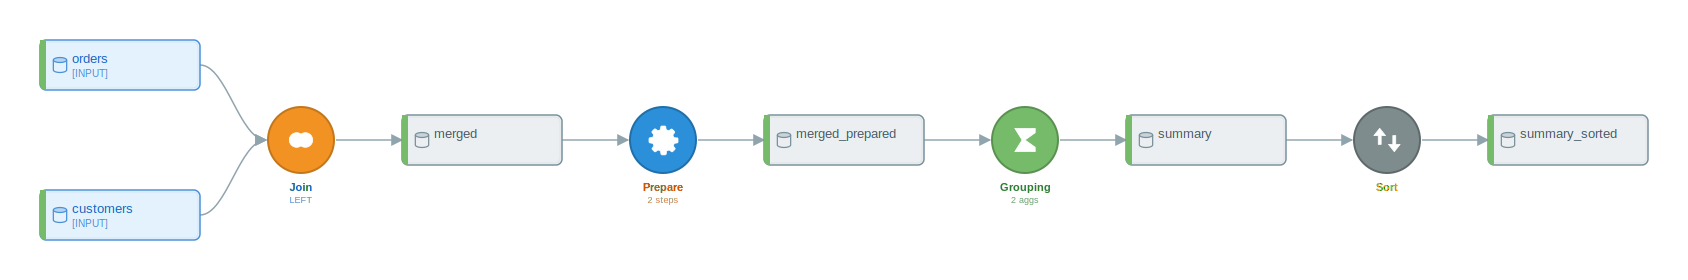

In [39]:
# SVG output (renders inline in Jupyter)
from IPython.display import SVG, display

svg_content = viz_flow.visualize(format="svg")
display(SVG(svg_content))

### PNG Export (Matplotlib)

The `MatplotlibVisualizer` produces polished PNG diagrams with DDODS-inspired styling — semantic colors, rounded nodes, and flow zone backgrounds.

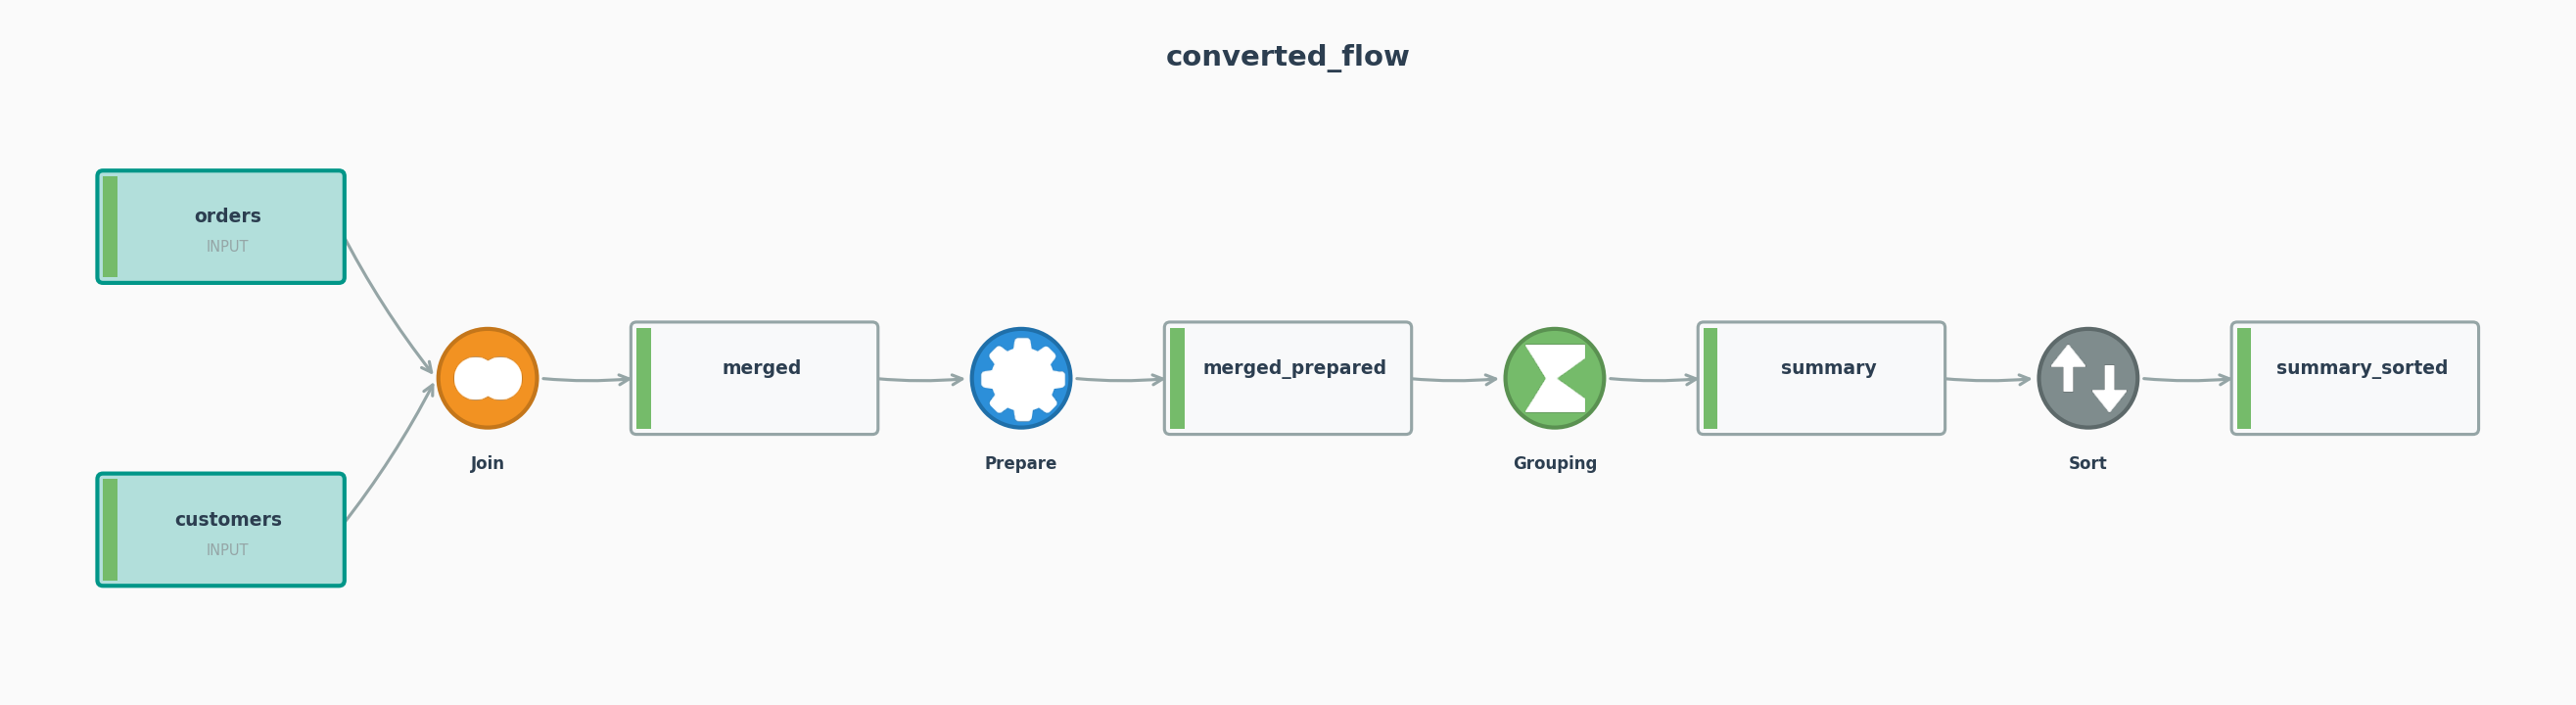

In [40]:
# PNG export - publication-quality diagram
from py2dataiku.visualizers import MatplotlibVisualizer
from IPython.display import Image, display

viz = MatplotlibVisualizer()
png_bytes = viz.render(viz_flow)
display(Image(png_bytes))

### 7.2 ASCII Visualization

Terminal-friendly text art. Great for logging and console output.

In [41]:
ascii_output = viz_flow.visualize(format="ascii")
print(ascii_output)

════════════════════════════════════════════════════════════════════════════════
                          DATAIKU FLOW: converted_flow  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 orders         │
                             │    [INPUT]        │
                              └──────────────────┘

                              ┌──────────────────┐
                              │ 📊 customers      │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⋈ JOIN      │
                                │ ──────────── │
                                │ LEFT         │
                                └──────────────┘

                                       │


### 7.3 HTML Visualization

Interactive canvas-based visualization.

In [42]:
from IPython.display import HTML

html_content = viz_flow.visualize(format="html")
print(f"HTML output length: {len(html_content)} characters")
print(f"First 200 chars: {html_content[:200]}...")

HTML output length: 43302 characters
First 200 chars: <!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>converted_flow - Dataiku Flow</title>
    <styl...


### 7.4 Mermaid Visualization

Mermaid diagrams are compatible with GitHub, Notion, and many documentation tools.

In [43]:
mermaid_output = viz_flow.visualize(format="mermaid")
print(mermaid_output)

flowchart TD
    subgraph inputs[Input Datasets]
        D0[(orders)]
        D1[(customers)]
    end
    D2[(merged)]
    D3[(merged_prepared)]
    D4[(summary)]
    D5[(summary_sorted)]
    R0{Join\n(LEFT)}
    R1{Prepare\n(2 steps)}
    R2{Grouping\n(2 aggs)}
    R3{Sort}
    D0 --> R0
    D1 --> R0
    R0 --> D2
    D2 --> R1
    R1 --> D3
    D3 --> R2
    R2 --> D4
    D4 --> R3
    R3 --> D5

    style D0 fill:#e1f5fe
    style D1 fill:#e1f5fe
    style R0 fill:#e3f2fd
    style R1 fill:#fff3e0
    style R2 fill:#e8f5e9
    style R3 fill:#f5f5f5


### 7.5 PlantUML Visualization

PlantUML diagrams for documentation and technical specs.

In [44]:
plantuml_output = viz_flow.visualize(format="plantuml")
print(plantuml_output)

@startuml
!theme plain
skinparam backgroundColor #FAFAFA
skinparam defaultFontName Arial
skinparam defaultFontSize 12

' Dataset styles
skinparam rectangle {
  BackgroundColor<<input>> #E3F2FD
  BorderColor<<input>> #4A90D9
  FontColor<<input>> #1565C0
  BackgroundColor<<output>> #E8F5E9
  BorderColor<<output>> #43A047
  FontColor<<output>> #2E7D32
  BackgroundColor<<intermediate>> #ECEFF1
  BorderColor<<intermediate>> #78909C
  FontColor<<intermediate>> #455A64
}

' Recipe styles (per-type, DSS-palette)
skinparam card {
  BackgroundColor<<prepare>> #2c8fd9
  BorderColor<<prepare>> #1f6fa9
  FontColor<<prepare>> #ffffff
  BackgroundColor<<sync>> #5d6d7e
  BorderColor<<sync>> #3d4d5e
  FontColor<<sync>> #ffffff
  BackgroundColor<<grouping>> #75bb6a
  BorderColor<<grouping>> #5a9151
  FontColor<<grouping>> #ffffff
  BackgroundColor<<window>> #9b59b6
  BorderColor<<window>> #7d3f97
  FontColor<<window>> #ffffff
  BackgroundColor<<join>> #f29222
  BorderColor<<join>> #c4761a
  FontColor<<j

### 7.6 Interactive Visualization

Enhanced HTML with pan/zoom, search, and export capabilities.

In [45]:
interactive_content = viz_flow.visualize(format="interactive")
print(f"Interactive output length: {len(interactive_content)} characters")
print(f"First 200 chars: {interactive_content[:200]}...")

Interactive output length: 37154 characters
First 200 chars: <!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>converted_flow - Interactive Flow Visualization...


### 7.7 Using `visualize_flow()` Directly

The module-level function `visualize_flow()` provides the same functionality.

In [46]:
# Same result, using the module-level function
ascii_v2 = visualize_flow(viz_flow, format="ascii")
print(ascii_v2)

════════════════════════════════════════════════════════════════════════════════
                          DATAIKU FLOW: converted_flow  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 orders         │
                             │    [INPUT]        │
                              └──────────────────┘

                              ┌──────────────────┐
                              │ 📊 customers      │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⋈ JOIN      │
                                │ ──────────── │
                                │ LEFT         │
                                └──────────────┘

                                       │


### 7.8 Convenience Methods on DataikuFlow

`DataikuFlow` provides shortcut methods for each format.

In [47]:
# Direct methods on flow
svg_out = viz_flow.to_svg()       # returns SVG string
ascii_out = viz_flow.to_ascii()   # returns ASCII string
html_out = viz_flow.to_html()     # returns HTML string
puml_out = viz_flow.to_plantuml() # returns PlantUML string

print(f"to_svg():      {len(svg_out)} chars")
print(f"to_ascii():    {len(ascii_out)} chars")
print(f"to_html():     {len(html_out)} chars")
print(f"to_plantuml(): {len(puml_out)} chars")

to_svg():      28610 chars
to_ascii():    3046 chars
to_html():     43302 chars
to_plantuml(): 6269 chars


---
## 8. Theme Support

py2dataiku provides two built-in themes: `DATAIKU_LIGHT` (default) and `DATAIKU_DARK`. You can also create custom themes.

In [48]:
# Inspect the light theme
print(f"Theme: {DATAIKU_LIGHT.name}")
print(f"Background:   {DATAIKU_LIGHT.background_color}")
print(f"Font family:  {DATAIKU_LIGHT.font_family}")
print(f"Dataset size: {DATAIKU_LIGHT.dataset_width}x{DATAIKU_LIGHT.dataset_height}")
print(f"Recipe size:  {DATAIKU_LIGHT.recipe_size}")
print(f"\nRecipe colors (bg, border, text):")
for name, colors in DATAIKU_LIGHT.recipe_colors.items():
    print(f"  {name:<12s}: {colors}")

Theme: dataiku-light
Background:   #FAFAFA
Font family:  Arial, Helvetica, sans-serif
Dataset size: 160x50
Recipe size:  70

Recipe colors (bg, border, text):
  prepare     : ('#FFF3E0', '#FF9800', '#E65100')
  join        : ('#E3F2FD', '#2196F3', '#1565C0')
  stack       : ('#F3E5F5', '#9C27B0', '#6A1B9A')
  grouping    : ('#E8F5E9', '#4CAF50', '#2E7D32')
  window      : ('#E0F7FA', '#00BCD4', '#00838F')
  split       : ('#FCE4EC', '#E91E63', '#AD1457')
  sort        : ('#FFFDE7', '#FFC107', '#FF8F00')
  distinct    : ('#EFEBE9', '#795548', '#4E342E')
  filter      : ('#FBE9E7', '#FF5722', '#D84315')
  python      : ('#E8EAF6', '#3F51B5', '#283593')
  sync        : ('#ECEFF1', '#607D8B', '#37474F')
  sample      : ('#F1F8E9', '#8BC34A', '#558B2F')
  pivot       : ('#E1F5FE', '#03A9F4', '#0277BD')
  top_n       : ('#FFF8E1', '#FFB300', '#FF6F00')
  default     : ('#F5F5F5', '#9E9E9E', '#616161')


In [49]:
# Inspect the dark theme
print(f"Theme: {DATAIKU_DARK.name}")
print(f"Background:  {DATAIKU_DARK.background_color}")
print(f"Input bg:    {DATAIKU_DARK.input_bg}")
print(f"Output bg:   {DATAIKU_DARK.output_bg}")

Theme: dataiku-dark
Background:  #1E1E1E
Input bg:    #1E3A5F
Output bg:   #1B3D1B


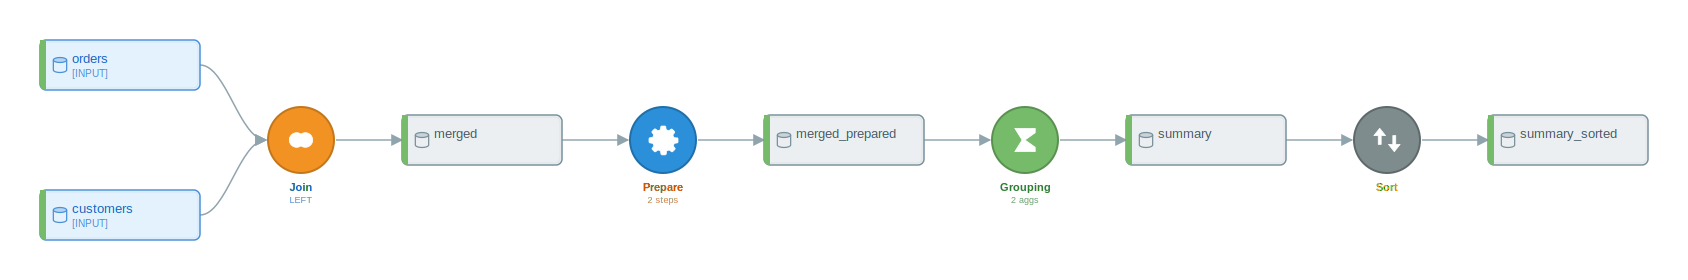

In [50]:
# Render with DATAIKU_LIGHT theme (default)
light_svg = SVGVisualizer(theme=DATAIKU_LIGHT).render(viz_flow)
display(SVG(light_svg))

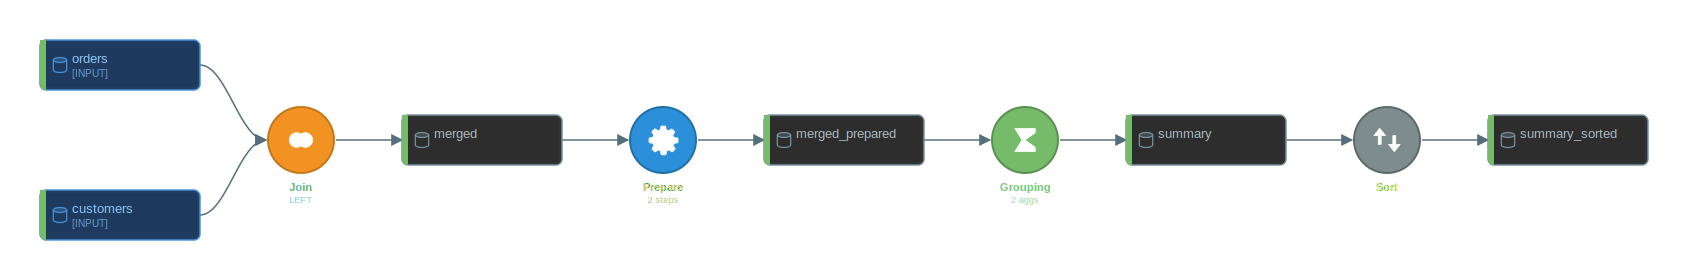

In [51]:
# Render with DATAIKU_DARK theme
dark_svg = SVGVisualizer(theme=DATAIKU_DARK).render(viz_flow)
display(SVG(dark_svg))

In [52]:
# You can also pass the theme via visualize_flow()
dark_ascii = ASCIIVisualizer(theme=DATAIKU_DARK).render(viz_flow)
print(dark_ascii)

════════════════════════════════════════════════════════════════════════════════
                          DATAIKU FLOW: converted_flow  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 orders         │
                             │    [INPUT]        │
                              └──────────────────┘

                              ┌──────────────────┐
                              │ 📊 customers      │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⋈ JOIN      │
                                │ ──────────── │
                                │ LEFT         │
                                └──────────────┘

                                       │


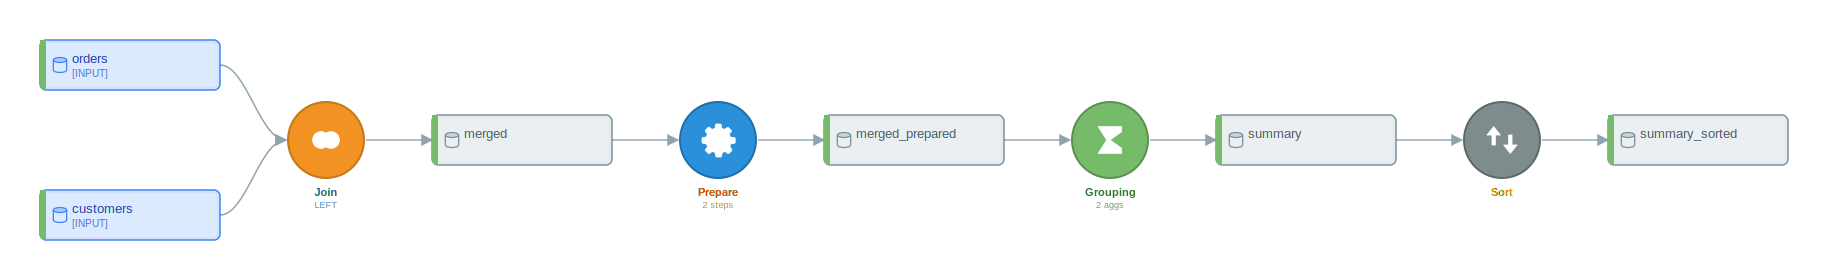

In [53]:
# Custom theme: create your own DataikuTheme
custom_theme = DataikuTheme(
    name="custom-blue",
    background_color="#F0F4FF",
    input_bg="#DBEAFE",
    input_border="#3B82F6",
    input_text="#1E40AF",
    output_bg="#D1FAE5",
    output_border="#10B981",
    output_text="#065F46",
    dataset_width=180,
    recipe_size=80,
)
custom_svg = SVGVisualizer(theme=custom_theme).render(viz_flow)
display(SVG(custom_svg))

---
## 9. Jupyter Inline Display with `_repr_svg_()` and `_repr_mimebundle_()`

When you evaluate a `DataikuFlow` as the last expression in a Jupyter cell it renders inline.
py-iku ships two rich-display methods so this works in every notebook environment:

- **`_repr_svg_()`** — Classic Jupyter (`jupyter notebook`) prefers this and gets a clean SVG.
- **`_repr_mimebundle_()`** — JupyterLab 3+, VS Code, and Colab call this; it returns both the
  SVG and a fallback text representation, so the diagram shows up everywhere.

Just type the flow at the bottom of a cell and let the notebook environment pick the
right method:

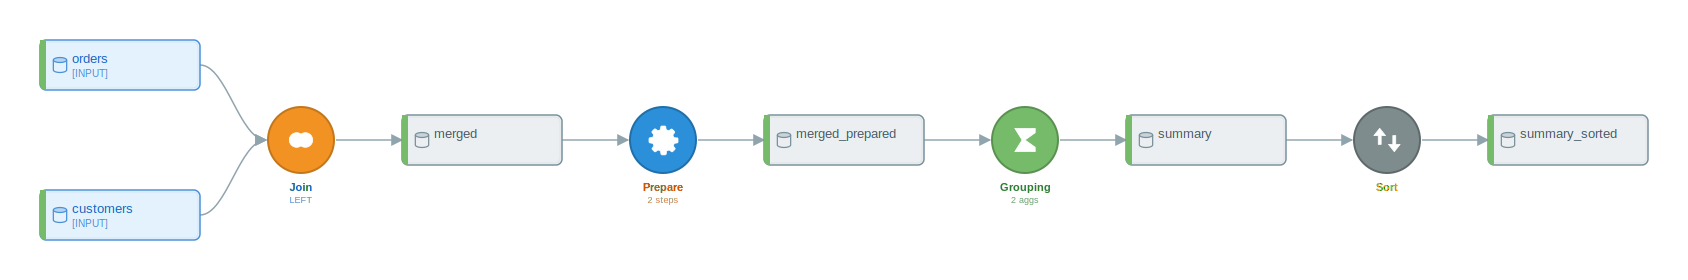

In [54]:
# Simply evaluate the flow -- Jupyter renders it as SVG automatically
viz_flow

---
## 10. YAML Serialization

`DataikuFlow` supports round-trip YAML serialization via `to_yaml()` and `from_yaml()`.

In [55]:
# Serialize flow to YAML
yaml_str = viz_flow.to_yaml()
print(yaml_str)

flow_name: converted_flow
generated_from: null
total_recipes: 4
total_datasets: 6
datasets:
- name: orders
  type: input
  connection_type: Filesystem
  schema: []
  source_variable: orders
  source_line: 5
  notes: []
- name: customers
  type: input
  connection_type: Filesystem
  schema: []
  source_variable: customers
  source_line: 6
  notes: []
- name: merged
  type: intermediate
  connection_type: Filesystem
  schema: []
  source_variable: null
  source_line: null
  notes: []
- name: merged_prepared
  type: intermediate
  connection_type: Filesystem
  schema: []
  source_variable: null
  source_line: null
  notes: []
- name: summary
  type: intermediate
  connection_type: Filesystem
  schema: []
  source_variable: null
  source_line: null
  notes: []
- name: summary_sorted
  type: intermediate
  connection_type: Filesystem
  schema: []
  source_variable: null
  source_line: null
  notes: []
recipes:
- name: join_1
  type: join
  inputs:
  - orders
  - customers
  outputs:
  - mer

In [56]:
# Round-trip: reconstruct from YAML
restored_flow = DataikuFlow.from_yaml(yaml_str)
print(f"Original:  {viz_flow}")
print(f"Restored:  {restored_flow}")
print(f"\nRecipes match: {len(viz_flow.recipes) == len(restored_flow.recipes)}")
print(f"Datasets match: {len(viz_flow.datasets) == len(restored_flow.datasets)}")

Original:  DataikuFlow(name='converted_flow', datasets=6, recipes=4)
Restored:  DataikuFlow(name='converted_flow', datasets=6, recipes=4)

Recipes match: True
Datasets match: True


In [57]:
# JSON round-trip also works
json_str = viz_flow.to_json(indent=2)
restored_json = DataikuFlow.from_json(json_str)
print(f"JSON round-trip: {len(restored_json.recipes)} recipes, {len(restored_json.datasets)} datasets")

JSON round-trip: 4 recipes, 6 datasets


---
## 11. Auto-detect format with `flow.save()` and `DataikuFlow.load()`

The lower-level `to_json` / `to_yaml` and `from_json` / `from_yaml` methods work with strings — you write the file yourself. The higher-level **`flow.save(path)`** detects the format from the file extension and writes the file for you, and **`DataikuFlow.load(path)`** is the symmetric counterpart. The same auto-detection works for `.svg`, `.html`, `.png`, `.pdf`, `.puml`, `.txt`, and `.md` — `save()` is the one method to use for any output format.

In [58]:
import tempfile
from pathlib import Path

with tempfile.TemporaryDirectory() as tmpdir:
    out_dir = Path(tmpdir)
    
    # Round-trip serialization (json/yaml)
    viz_flow.save(out_dir / 'flow.json')
    viz_flow.save(out_dir / 'flow.yaml')
    
    # Visual exports (svg/html/png — same one method)
    viz_flow.save(out_dir / 'flow.svg')
    viz_flow.save(out_dir / 'flow.html')
    
    # Symmetric load
    reloaded = DataikuFlow.load(out_dir / 'flow.json')
    
    print('Saved files (size in bytes):')
    for f in sorted(out_dir.iterdir()):
        print(f'  {f.name}: {f.stat().st_size}')
    print()
    print(f'Round-trip OK: {len(reloaded.recipes)} recipes match original ({len(viz_flow.recipes)} recipes).')


Saved files (size in bytes):


  flow.html: 43307
  flow.json: 3423
  flow.svg: 28610
  flow.yaml: 2080

Round-trip OK: 4 recipes match original (4 recipes).


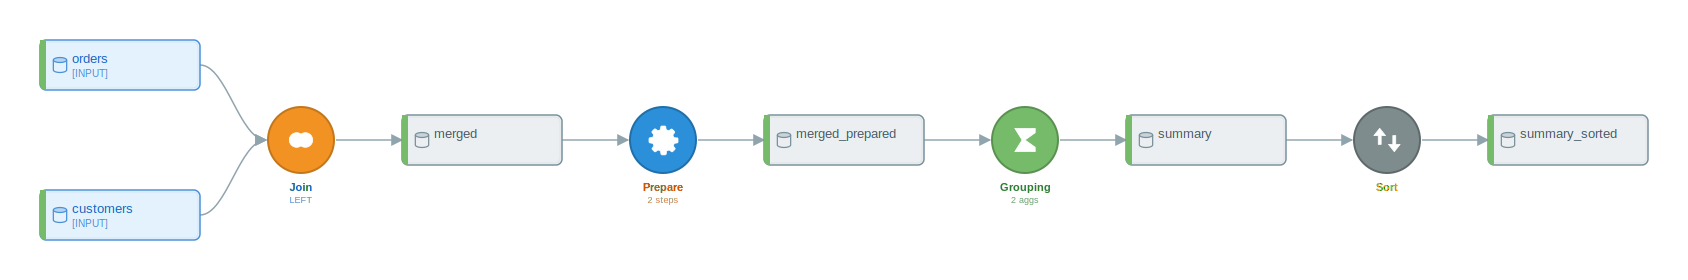

In [59]:
# Verify the restored flow visualizes correctly
restored_flow

---
## 11. Flow Querying Methods

`DataikuFlow` provides methods for querying recipes and datasets.

In [60]:
# Iteration protocol: len() and for-loop
print(f"Number of recipes: {len(viz_flow)}")
print()

for recipe in viz_flow:
    print(f"  {recipe}")

Number of recipes: 4

  DataikuRecipe(name='join_1', type=join)
  DataikuRecipe(name='prepare_2', type=prepare)
  DataikuRecipe(name='grouping_3', type=grouping)
  DataikuRecipe(name='sort_4', type=sort)


In [61]:
# Query by type
grouping_recipes = viz_flow.get_recipes_by_type(RecipeType.GROUPING)
print(f"Grouping recipes: {grouping_recipes}")

prepare_recipes = viz_flow.get_recipes_by_type(RecipeType.PREPARE)
print(f"Prepare recipes:  {prepare_recipes}")

Grouping recipes: [DataikuRecipe(name='grouping_3', type=grouping)]
Prepare recipes:  [DataikuRecipe(name='prepare_2', type=prepare)]


In [62]:
# Dataset classification
print(f"Input datasets:        {[ds.name for ds in viz_flow.input_datasets]}")
print(f"Intermediate datasets: {[ds.name for ds in viz_flow.intermediate_datasets]}")
print(f"Output datasets:       {[ds.name for ds in viz_flow.output_datasets]}")

Input datasets:        ['orders', 'customers']
Intermediate datasets: ['merged', 'merged_prepared', 'summary', 'summary_sorted']
Output datasets:       []


---
## 12. DAG Analysis

The `flow.graph` property provides a `FlowGraph` for DAG analysis.
Let's explore the structure of our `viz_flow` from section 7.

In [63]:
# Access the DAG from the flow we built in section 7
dag = viz_flow.graph
print(f"Flow graph: {dag}")
print(f"Dataset nodes: {len(dag.dataset_nodes)}")
print(f"Recipe nodes: {len(dag.recipe_nodes)}")

# Topological sort -- the execution order
print("\nExecution order (topological sort):")
for i, name in enumerate(dag.topological_sort(), 1):
    node = dag.get_node(name)
    print(f"  {i}. [{node.node_type.value}] {name}")

# Roots and leaves
print(f"\nRoot nodes (sources): {dag.get_roots()}")
print(f"Leaf nodes (sinks): {dag.get_leaves()}")

# Cycle detection and connected components
print(f"Cycles: {dag.detect_cycles()}")
print(f"Connected components: {len(dag.find_disconnected_subgraphs())}")

Flow graph: FlowGraph(nodes=10, edges=9)
Dataset nodes: 6
Recipe nodes: 4

Execution order (topological sort):
  1. [dataset] orders
  2. [dataset] customers
  3. [recipe] recipe:join_1
  4. [dataset] merged
  5. [recipe] recipe:prepare_2
  6. [dataset] merged_prepared
  7. [recipe] recipe:grouping_3
  8. [dataset] summary
  9. [recipe] recipe:sort_4
  10. [dataset] summary_sorted

Root nodes (sources): ['orders', 'customers']
Leaf nodes (sinks): ['summary_sorted']
Cycles: []
Connected components: 1


---
## 13. Column Lineage

The `get_column_lineage()` method traces a column through the flow's recipes
to discover its origin and transformations.

In [64]:
# Trace the 'revenue' column through the viz_flow
lineage = viz_flow.get_column_lineage("revenue")
print(f"Column: {lineage.column}")
print(f"Final dataset: {lineage.final_dataset}")
print(f"Origin dataset: {lineage.origin_dataset}")
print(f"Origin column: {lineage.origin_column}")
print(f"Transformations: {lineage.transformations}")

# Also trace 'quantity'
lineage_qty = viz_flow.get_column_lineage("quantity")
print(f"\nColumn 'quantity':")
print(f"  Origin: {lineage_qty.origin_dataset} -> Final: {lineage_qty.final_dataset}")
print(f"  Transformations: {lineage_qty.transformations}")

Column: revenue
Final dataset: summary_sorted
Origin dataset: orders
Origin column: revenue
Transformations: [{'type': 'join', 'recipe': 'join_1', 'join_type': 'LEFT'}, {'type': 'aggregation', 'recipe': 'grouping_3', 'function': 'SUM', 'source_column': 'revenue'}]

Column 'quantity':
  Origin: orders -> Final: summary_sorted
  Transformations: [{'type': 'join', 'recipe': 'join_1', 'join_type': 'LEFT'}, {'type': 'aggregation', 'recipe': 'grouping_3', 'function': 'AVG', 'source_column': 'quantity'}]


---
## 14. Format Comparison Guide

| Format | Best For | Rendering | Interactivity |
|--------|----------|-----------|---------------|
| **ASCII** | Terminal output, logs, CI/CD | Plain text | None |
| **SVG** | Documentation, Jupyter inline | Browser/viewer | None |
| **HTML** | Web dashboards, sharing | Browser | Basic |
| **Mermaid** | GitHub READMEs, Notion, Markdown | Mermaid renderer | None |
| **PlantUML** | Technical docs, UML tools | PlantUML renderer | None |
| **Interactive** | Exploration, large flows | Browser | Pan/zoom/search |

In [65]:
# Compare output sizes across all formats
print(f"{'Format':<15s} {'Output Size':>12s}")
print("-" * 28)
for fmt in ["ascii", "svg", "html", "mermaid", "plantuml", "interactive"]:
    output = viz_flow.visualize(format=fmt)
    print(f"{fmt:<15s} {len(output):>10,d} chars")

Format           Output Size
----------------------------
ascii                3,046 chars
svg                 28,610 chars
html                43,302 chars
mermaid                558 chars
plantuml             6,269 chars
interactive         37,154 chars


---
## Summary

In this notebook we covered:

1. **RecipeType enum** -- All 37 recipe types organized by category (visual, code, ML)
2. **Recipe conversions** -- Pandas code that maps to PREPARE, GROUPING, JOIN, STACK, SORT, DISTINCT, TOP_N, WINDOW, PIVOT, SPLIT, and SAMPLING recipes
3. **DataikuRecipe attributes** -- `name`, `recipe_type`, `inputs`, `outputs`, `settings`, `steps`, `group_keys`, `aggregations`, etc.
4. **Factory methods** -- `create_grouping()`, `create_join()`, `create_prepare()`, `create_python()`
5. **Recipe settings classes** -- `GroupingSettings`, `JoinSettings`, `WindowSettings`, `SortSettings`, `PivotSettings`, `SplitSettings`, `SamplingSettings`, `DistinctSettings`, `TopNSettings`, `StackSettings`
6. **Visualization formats** -- SVG, ASCII, HTML, Mermaid, PlantUML, Interactive
7. **Theme support** -- `DATAIKU_LIGHT`, `DATAIKU_DARK`, and custom `DataikuTheme`
8. **Jupyter integration** -- `_repr_svg_()` for automatic inline rendering
9. **YAML/JSON serialization** -- `to_yaml()`/`from_yaml()`, `to_json()`/`from_json()` round-trips

**Next:** Continue to `03_advanced.ipynb` to explore processors, DAG analysis, and flow optimization.